A noisy ECG-like signal is generated by summing a base heartbeat sinusoid with two interference signals — a high-frequency noise component and a slow baseline wander:

$$x_1(n) = \cos(2\pi(2)t)$$

$$x_2(n) = 0.5\cos(2\pi(50)t)$$

$$x_3(n) = 0.3\cos(2\pi(120)t)$$

$$x(n) = x_1(n) + x_2(n) + x_3(n)$$

Use a sampling rate of 1000 Hz over 2 seconds.

a. Plot $x(n)$ and observe how the interference distorts the base signal.

b. Design a 10-point moving average filter $h(n)$ and manually implement the convolution $y(n) = x(n) * h(n)$ using loops. Plot $y(n)$ alongside $x(n)$.

In [176]:
import numpy as np
import matplotlib.pyplot as plt

In [177]:
# Parameters required
start = 0
end = 2
fs = 1000
f1 = 2
f2 = 50
f3 = 120
time = np.arange(start, end, 1/fs)
kernel_size = 10

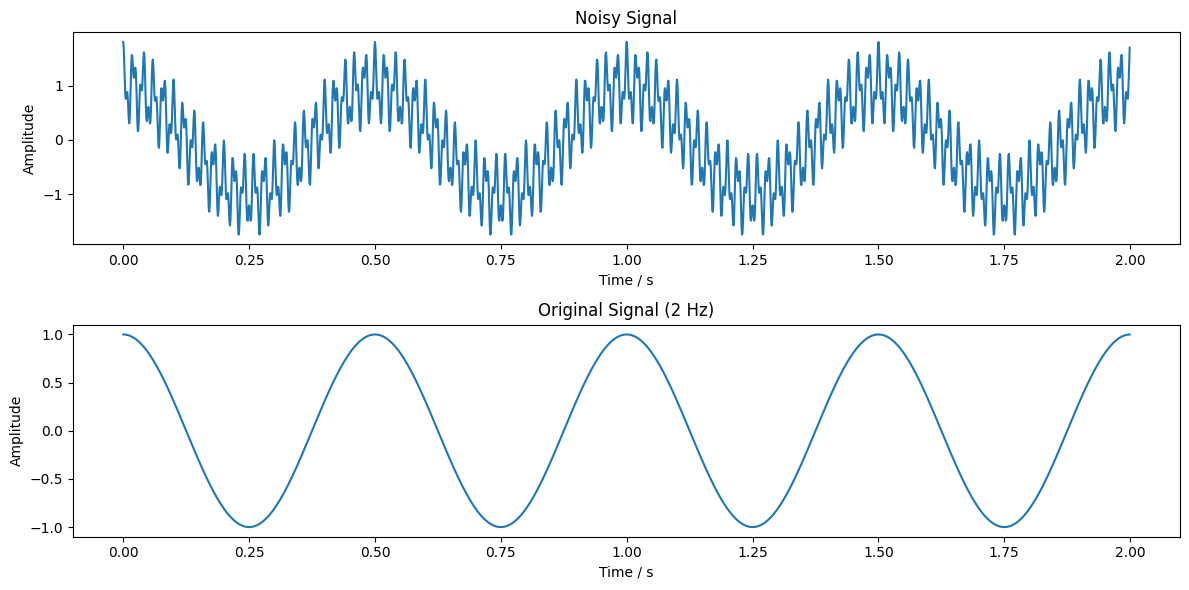

In [178]:
# Generating the signal and kernel
base = np.cos(2 * np.pi * f1 * time)
noise1 = 0.5 * np.cos(2 * np.pi * f2 * time)
noise2 = 0.3 * np.cos(2 * np.pi * f3 * time)
signal = base + noise1 + noise2

kernel = np.ones(kernel_size) / kernel_size

X = len(signal)
Y = len(kernel)
conv_length = X + Y - 1

# Plotting
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, signal)
plt.title('Noisy Signal')
plt.xlabel('Time / s')
plt.ylabel('Amplitude')
plt.subplot(2, 1, 2)
plt.plot(time, base)
plt.title('Original Signal (2 Hz)')
plt.xlabel('Time / s')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

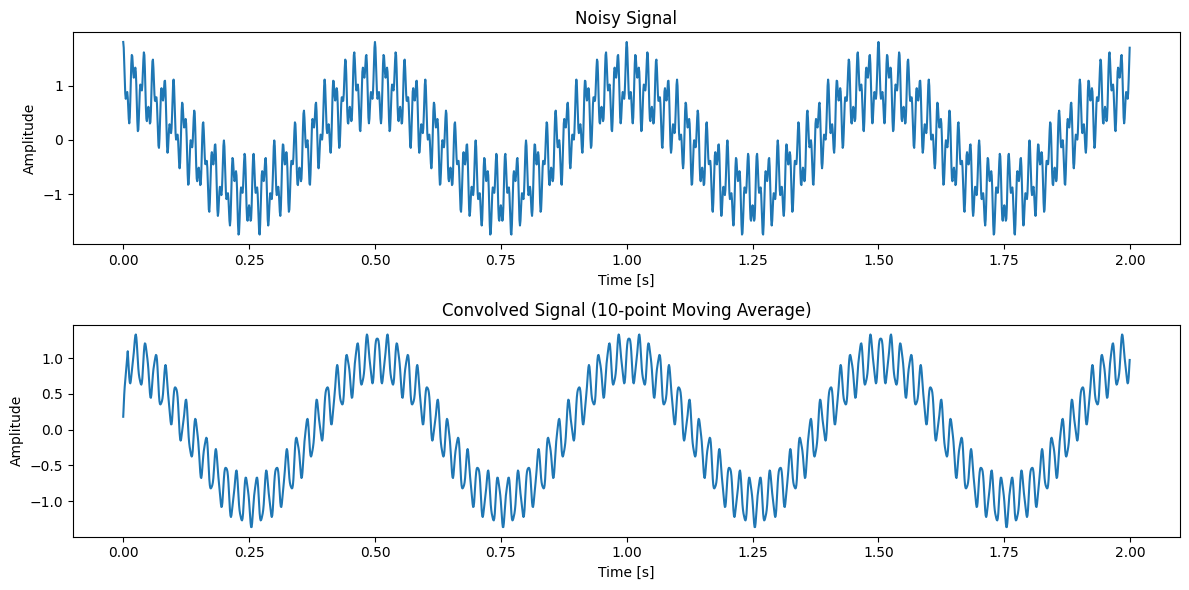

In [179]:
# Implementing convolution (10-point moving average filter)
conv = np.zeros(conv_length)

for n in range(conv_length):
    for k in range(X):
        j = n - k      # flipping the kernel index
        if j >=0 and j < Y:
            conv[n] += signal[k] * kernel[j]


# Plotting the convolved signal
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(time, signal)
plt.title('Noisy Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.subplot(2, 1, 2)
plt.plot(time, conv[:len(time)])  
plt.title('Convolved Signal (10-point Moving Average)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

- This exercise demostrates convolution in action, with a filter kernel of size 10. The kernel is simply the impulse response h[n] of the filter, which is flipped during the operation.

- The code:
    ```python
    for n in range(conv_length):
        for i in range(X):
            for j in range(Y):
                if i + j == n:
                    conv[n] += signal[i] * kernel[j]
    ```
- could have been used but has two issues:
    - The time complexity is O($N^2M$) which takes time for long signals, compared to the code implemented in this notebook for which the complexity is O($NM$).

    - This code fails to flip the h[n] signal.